In [11]:
!pip install transformers -q

In [26]:
import random

# Word pools for each class
class_word_pools = {
    'Basketball'  : ["player", "dribbling", "shooting", "passing",
                     "court", "basketball", "hoop", "match", "jump", "defense"],
    'Biking'      : ["riding", "bicycle", "road", "cycling", "outdoor",
                     "speed", "trail", "wheels", "pedaling", "helmet"],
    'Bowling'     : ["bowling", "pins", "lane", "ball", "strike",
                     "spare", "throw", "alley", "roll", "knock"],
    'CliffDiving' : ["cliff", "diving", "jump", "water", "height",
                     "rocky", "splash", "athlete", "freefall", "ocean"],
    'GolfSwing'   : ["golf", "swing", "club", "green", "course",
                     "ball", "fairway", "putt", "hole", "drive"],
    'HorseRiding' : ["horse", "riding", "equestrian", "gallop", "field",
                     "saddle", "track", "trot", "outdoor", "stable"],
    'Skiing'      : ["skiing", "snow", "mountain", "slope", "downhill",
                     "poles", "winter", "speed", "ski", "resort"],
    'Surfing'     : ["surfing", "wave", "ocean", "board", "beach",
                     "ride", "water", "surfer", "sea", "balance"],
    'TennisSwing' : ["tennis", "racket", "court", "swing", "ball",
                     "serve", "player", "match", "volley", "baseline"],
    'SkateBoarding': ["skateboard", "trick", "ramp", "outdoor", "skater",
                      "jump", "grind", "wheels", "park", "flip"]
}

def generate_random_description(cls, num_words=5):
    """Pick random words from pool — different each time"""
    words = random.sample(class_word_pools[cls], num_words)
    random.shuffle(words)
    return " ".join(words)

# Test it
for cls in selected_classes:
    d1 = generate_random_description(cls)
    d2 = generate_random_description(cls)
    print(f"{cls:15} → '{d1}'")
    print(f"{'':15}   '{d2}'")
    print()

Basketball      → 'shooting player basketball defense dribbling'
                  'hoop match dribbling court jump'

Biking          → 'outdoor speed trail riding pedaling'
                  'pedaling speed road outdoor trail'

Bowling         → 'throw lane alley roll ball'
                  'strike roll spare lane throw'

CliffDiving     → 'cliff diving freefall jump ocean'
                  'diving ocean athlete water freefall'

GolfSwing       → 'hole golf drive fairway course'
                  'course green drive club putt'

HorseRiding     → 'field track riding equestrian horse'
                  'stable saddle gallop field outdoor'

Skiing          → 'ski snow speed poles skiing'
                  'mountain skiing resort ski winter'

Surfing         → 'ride beach balance wave water'
                  'surfer surfing ride water sea'

TennisSwing     → 'racket ball tennis baseline volley'
                  'volley ball baseline court player'

SkateBoarding   → 'flip outdoor skate

In [27]:
from transformers import DistilBertTokenizer, DistilBertModel

tokenizer  = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
bert_model = bert_model.to(device)
bert_model.eval()

for param in bert_model.parameters():
    param.requires_grad = False

def get_text_features(text):
    tokens = tokenizer(
        text,
        return_tensors   = 'pt',
        padding          = True,
        truncation       = True,
        max_length       = 32
    ).to(device)

    with torch.no_grad():
        output = bert_model(**tokens)

    return output.last_hidden_state[:, 0, :].cpu()

print("DistilBERT ready!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT ready!


In [28]:
from torchvision import models

class MultimodalFusionModel(nn.Module):
    def __init__(self, num_classes=10, hidden_size=512, num_layers=2):
        super(MultimodalFusionModel, self).__init__()

        # --- Visual Branch (CNN + LSTM) ---
        resnet = models.resnet50(pretrained=True)

        # Unfreeze layer4
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name

        self.cnn = nn.Sequential(*list(resnet.children())[:-1])

        self.lstm = nn.LSTM(
            input_size  = 2048,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3
        )

        # --- Text Branch ---
        # DistilBERT output is 768
        self.text_projector = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # --- Fusion Layer ---
        self.fusion = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.5),    # ✅ higher dropout
            nn.Linear(256, num_classes)
        )

    def forward(self, video, text_feat):
        # --- Visual path ---
        batch_size, frames, C, H, W = video.shape
        video = video.view(batch_size * frames, C, H, W)

        with torch.no_grad():
            cnn_out = self.cnn(video)  # (batch*frames, 2048, 1, 1)

        cnn_out  = cnn_out.view(batch_size, frames, -1)  # (batch, frames, 2048)
        lstm_out, _ = self.lstm(cnn_out)
        visual_feat = lstm_out[:, -1, :]                 # (batch, 512)

        # --- Text path ---
        text_feat = text_feat.squeeze(1)                 # (batch, 768)
        text_feat = self.text_projector(text_feat)       # (batch, 512)

        # --- Fusion ---
        fused = torch.cat([visual_feat, text_feat], dim=1)  # (batch, 1024)
        out   = self.fusion(fused)                           # (batch, num_classes)

        return out

# Initialize
fusion_model = MultimodalFusionModel(num_classes=10).to(device)
print("Multimodal Fusion Model ready!")
print(f"Trainable parameters: {sum(p.numel() for p in fusion_model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Multimodal Fusion Model ready!
Trainable parameters: 22,971,658


In [29]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, samples, selected_classes,
                 transform=None, training=False):
        self.samples          = samples
        self.selected_classes = selected_classes
        self.transform        = transform
        self.training         = training

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cls_name          = self.selected_classes[label]

        # Load video frames
        frames = sorted(os.listdir(video_path))
        frame_tensors = []
        for frame_file in frames:
            frame_path = os.path.join(video_path, frame_file)
            image      = Image.open(frame_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            frame_tensors.append(image)

        video_tensor = torch.stack(frame_tensors)

        # ✅ Generate DIFFERENT random description every time
        if self.training:
            # During training: random 4-6 words, shuffled
            num_words = random.randint(4, 6)
            desc      = generate_random_description(cls_name, num_words)
        else:
            # During val: fixed 5 words (consistent evaluation)
            random.seed(idx)
            desc = generate_random_description(cls_name, 5)
            random.seed()     # reset seed

        text_feature = get_text_features(desc).squeeze(0)

        return video_tensor, text_feature, label

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Build samples
frames_path  = '/content/ucf_frames'
class_to_idx = {cls: idx for idx, cls in enumerate(selected_classes)}

all_samples = []
for cls in selected_classes:
    cls_path = os.path.join(frames_path, cls)
    if not os.path.exists(cls_path):
        continue
    for video_name in os.listdir(cls_path):
        video_path = os.path.join(cls_path, video_name)
        if len(os.listdir(video_path)) == 16:
            all_samples.append((video_path, class_to_idx[cls]))

# Split
random.shuffle(all_samples)
split         = int(0.8 * len(all_samples))
train_samples = all_samples[:split]
val_samples   = all_samples[split:]

train_dataset = MultimodalDataset(train_samples, selected_classes,
                                   transform, training=True)
val_dataset   = MultimodalDataset(val_samples,   selected_classes,
                                   transform, training=False)

# ✅ num_workers=0 to avoid CUDA issues with dynamic BERT calls
train_loader = DataLoader(train_dataset, batch_size=8,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8,
                          shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 1062 | Val: 266


In [30]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=0.0001
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

best_val_acc    = 0.0
EPOCHS          = 5
checkpoint_path = '/content/drive/MyDrive/NewsImageCNN/checkpoints/fusion_best.pth'

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    for phase in ['train', 'val']:
        if phase == 'train':
            fusion_model.train()
            loader = train_loader
        else:
            fusion_model.eval()
            loader = val_loader

        running_loss     = 0.0
        running_corrects = 0

        for videos, text_feats, labels in loader:
            videos     = videos.to(device)
            text_feats = text_feats.to(device)
            labels     = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs      = fusion_model(videos, text_feats)
                loss         = criterion(outputs, labels)
                _, preds     = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss     += loss.item() * videos.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc  = running_corrects.double() / len(loader.dataset)

        print(f"{phase.upper()} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

            if epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                torch.save(fusion_model.state_dict(), checkpoint_path)
                print(f"  ✅ Best model saved! Val Acc: {best_val_acc:.4f}")

print(f"\nTraining Complete! Best Val Acc: {best_val_acc:.4f}")


Epoch 1/5
----------------------------------------
TRAIN — Loss: 1.9177  Acc: 0.3663
VAL — Loss: 1.1223  Acc: 0.7368
  ✅ Best model saved! Val Acc: 0.7368

Epoch 2/5
----------------------------------------
TRAIN — Loss: 1.0704  Acc: 0.6667
VAL — Loss: 0.4726  Acc: 0.8759
  ✅ Best model saved! Val Acc: 0.8759

Epoch 3/5
----------------------------------------
TRAIN — Loss: 0.5582  Acc: 0.8277
VAL — Loss: 0.2641  Acc: 0.9211
  ✅ Best model saved! Val Acc: 0.9211

Epoch 4/5
----------------------------------------
TRAIN — Loss: 0.3524  Acc: 0.9049
VAL — Loss: 0.1217  Acc: 0.9662
  ✅ Best model saved! Val Acc: 0.9662

Epoch 5/5
----------------------------------------
TRAIN — Loss: 0.2428  Acc: 0.9313
VAL — Loss: 0.0875  Acc: 0.9737
  ✅ Best model saved! Val Acc: 0.9737

Training Complete! Best Val Acc: 0.9737


Classification Report:
               precision    recall  f1-score   support

   Basketball       1.00      1.00      1.00        23
       Biking       1.00      0.94      0.97        18
      Bowling       1.00      1.00      1.00        25
  CliffDiving       0.96      1.00      0.98        22
    GolfSwing       1.00      0.89      0.94        35
  HorseRiding       0.91      1.00      0.95        40
       Skiing       0.96      1.00      0.98        25
      Surfing       1.00      1.00      1.00        26
  TennisSwing       1.00      1.00      1.00        35
SkateBoarding       0.94      0.88      0.91        17

     accuracy                           0.97       266
    macro avg       0.98      0.97      0.97       266
 weighted avg       0.98      0.97      0.97       266



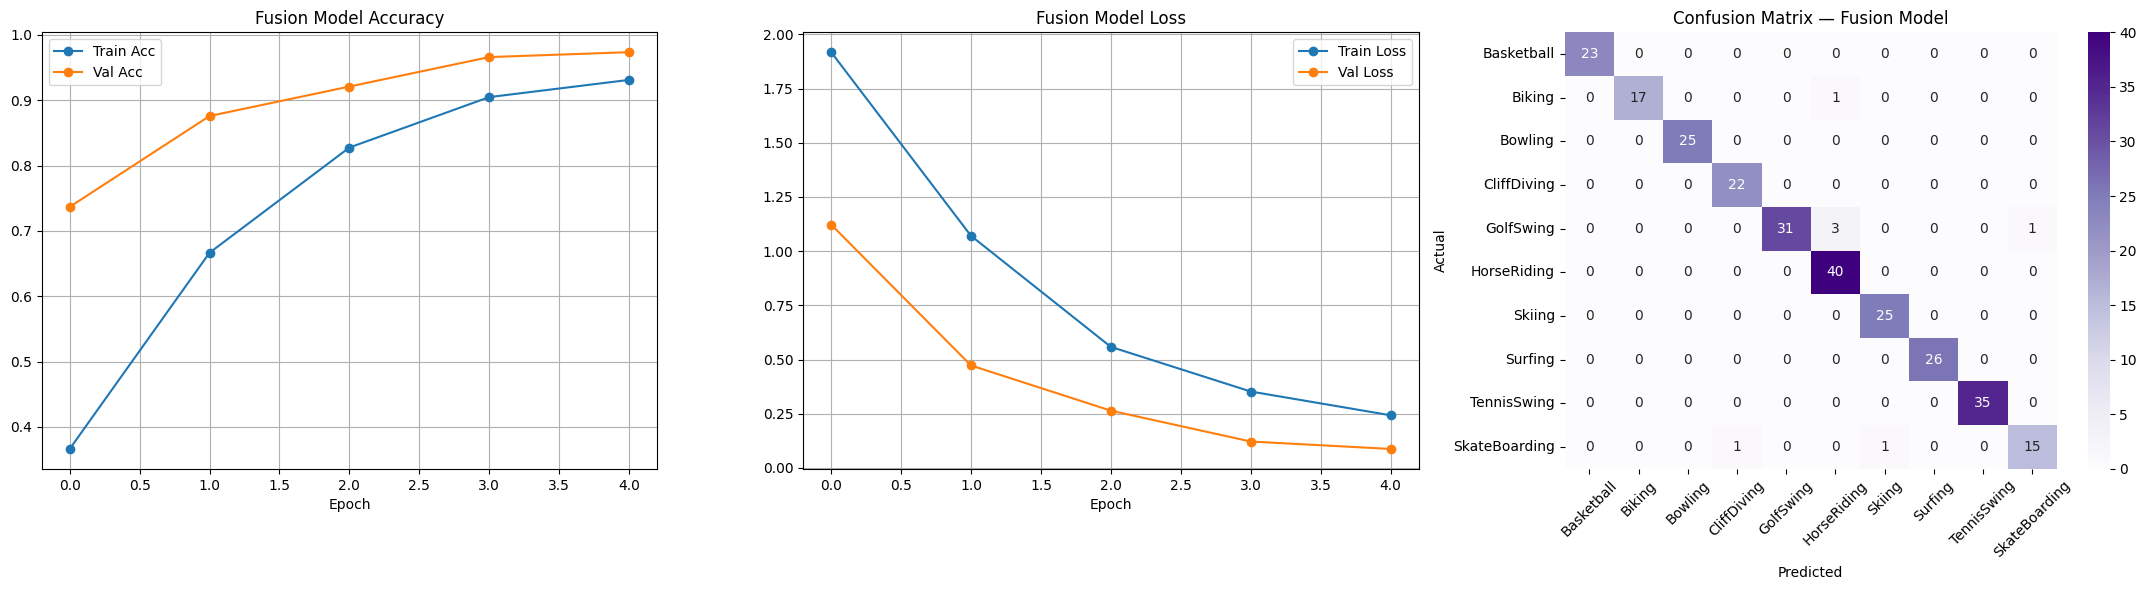

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
fusion_model.load_state_dict(torch.load(checkpoint_path))
fusion_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for videos, text_feats, labels in val_loader:
        videos     = videos.to(device)
        text_feats = text_feats.to(device)
        outputs    = fusion_model(videos, text_feats)
        _, preds   = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=selected_classes))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].plot(history['train_acc'], label='Train Acc', marker='o')
axes[0].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[0].set_title('Fusion Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[1].set_title('Fusion Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=selected_classes,
            yticklabels=selected_classes, ax=axes[2])
axes[2].set_title('Confusion Matrix — Fusion Model')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NewsImageCNN/fusion_results.png', dpi=150)
plt.show()